# Custom Vision Partitioners

> Any custom vision paritioner that is not a built-in paritioner in flower-dataset library.


In [ ]:
#| default_exp data.vision.partitioners

In [ ]:
#| hide
from nbdev.showdoc import *

In [6]:
#| export
import numpy as np
from fastcore.utils import *
import warnings
from typing import Any, Dict, Literal, List, Optional, Union

import datasets
from flwr_datasets.common.typing import NDArray
from flwr_datasets.partitioner.partitioner import Partitioner


## Rotated and Masked MNIST


In [2]:
#| export
class RotatedPatchedPartitioner(Partitioner):
    def __init__(self, num_partitions=40, num_rotations=4, patch_size=2, seed=42):
        super().__init__()
        self._num_partitions = num_partitions
        self.num_rotations = num_rotations
        self.patch_size = patch_size
        self.noise_levels = [0.0, 0.15, 0.30, 0.50]
        self.root_seed = int((np.e ** np.euler_gamma) ** np.pi * 1000)
        self.seed = self.root_seed

    @property
    def num_partitions(self) -> int:
        return self._num_partitions

    def load_partition(self, partition_id: int):
        dataset = self.dataset
        total_len = len(dataset)
        
        # 1. Standard Slicing
        samples_per_client = total_len // self._num_partitions
        start_idx = partition_id * samples_per_client
        end_idx = (partition_id + 1) * samples_per_client
        partition = dataset.select(range(start_idx, end_idx))
        
        # 2. Define the clusters seen in the paper (Figure A1)
        # We map partition_id to one of 4 clusters
        num_clusters = 4
        clients_per_cluster = self._num_partitions // num_clusters
        cluster_idx = partition_id // clients_per_cluster
        
        # 3. Assign rotation and noise based on the cluster index
        # Cluster 1: 0°, 0% Masked
        # Cluster 2: 90°, 0% Masked 
        # Cluster 3: 180°, 15% Masked
        # Cluster 4: 270°, 30-50% Masked (we can alternate or use partition_id for variety)
        
        rotations = [0, 1, 2, 3] # k values for 0, 90, 180, 270 degrees
        rotation_k = rotations[cluster_idx]
        
        # Map clusters to noise levels as per Figure A1
        if cluster_idx == 0: # Cluster 1
            current_noise = 0.0
        elif cluster_idx == 1: # Cluster 2
            current_noise = 0.0
        elif cluster_idx == 2: # Cluster 3
            current_noise = 0.15
        else: # Cluster 4 (Alternating 30% and 50% for high noise variety)
            current_noise = 0.30 if (partition_id % 2 == 0) else 0.50

        # 4. Generate the silo-specific mask
        if self.patch_size > 0 and current_noise > 0:
            # Pass current_noise to the mask generator
            mask = self._generate_mask(partition_id, current_noise)
        else:
            # Return a zero mask if no noise is applied
            mask = np.zeros((28, 28), dtype=np.float32)

        print(f"Partition {partition_id}: Cluster {cluster_idx + 1}, "
            f"Rot: {rotation_k * 90}°, Noise: {current_noise * 100}%")
        
        # 5. Attach metadata for the VisionBlock transform
        partition.rotation_k = rotation_k
        partition.silo_mask = mask
        partition.noise_level = current_noise # Useful for logging
        
        return partition
    
    def _generate_mask(self, p_id, noise_level):
        # Authors use a seed based on the root_seed + silo_id for intra-cluster diff
        rand = np.random.default_rng(seed=self.root_seed + p_id)
        w, h = 28, 28
        
        # Determine grid size for patches
        grid_w = int(np.ceil(w / self.patch_size))
        grid_h = int(np.ceil(h / self.patch_size))
        
        # Create mask: 1 is a white patch, 0 is original data
        mask_grid = rand.choice([0, 1], size=(grid_w, grid_h), 
                                p=[1 - noise_level, noise_level])
        
        # Upscale to 28x28
        noise_patch = np.kron(mask_grid, np.ones((self.patch_size, self.patch_size)))
        return noise_patch[:w, :h] # Crop to exact MNIST size
    

In [3]:
#| hide
from flwr_datasets import FederatedDataset

partitioner = RotatedPatchedPartitioner(num_partitions=40, patch_size= 0)
test_partitioner = RotatedPatchedPartitioner(num_partitions=40, patch_size= 0)
fds = FederatedDataset(
    dataset="ylecun/mnist", 
    partitioners={"train": partitioner, "test": test_partitioner}
)

Partition 12: Cluster 2, Rot: 90°, Noise: 0.0%


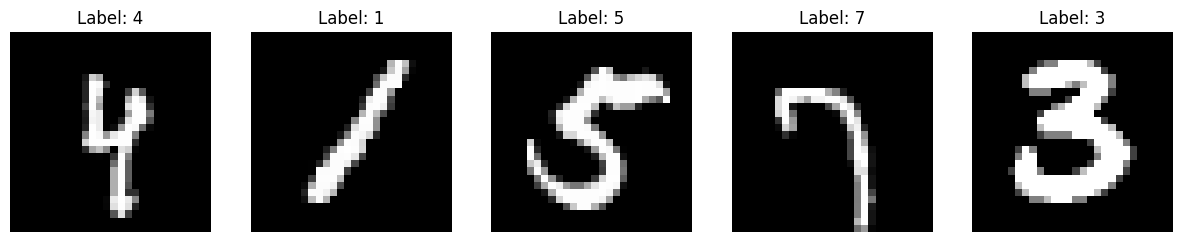

In [4]:
#| hide
import matplotlib.pyplot as plt
def plot_client_samples(partition, num_samples=5):
    fig, axes = plt.subplots(1, num_samples, figsize=(15, 3))
    for i in range(num_samples):
        img = np.array(partition[i]['image']).squeeze()  # Remove channel dimension if present
        label = partition[i]['label']
        axes[i].imshow(img, cmap='gray')
        axes[i].set_title(f"Label: {label}")
        axes[i].axis('off')
    plt.show()

idx = np.random.randint(0, fds.partitioners["train"].num_partitions)
client_data = fds.load_partition(idx, "train")
plot_client_samples(client_data, num_samples=5)

## Variable Classes Partitioner

> Different number of classes per client Partitioner

In [7]:
#| export
"""Flexible pathological partitioner with variable classes per partition."""



class VariableClassPartitioner(Partitioner):
    """Partition dataset with a variable number of classes per partition.

    Each partition can have a different number of classes assigned to it.
    This extends the pathological partitioning concept to support heterogeneous
    class distributions across clients.

    Parameters
    ----------
    num_partitions : int
        The total number of partitions (clients).
    partition_by : str
        Column name of the labels (targets) based on which partitioning works.
    num_classes_per_partition : Union[int, List[int], Dict[int, int]]
        Controls how many unique classes each partition receives. Accepts:

        - ``int``: Every partition gets the same number of classes (identical
          to the original PathologicalPartitioner behaviour).
        - ``List[int]``: Element ``i`` specifies the class count for partition
          ``i``. Length must equal ``num_partitions``.
        - ``Dict[int, int]``: Maps ``partition_id -> num_classes``. Any
          partition not present in the dict falls back to
          ``default_num_classes``.
    default_num_classes : int, optional
        Fallback class count used when a partition is absent from a dict
        supplied to ``num_classes_per_partition``. Defaults to 1.
    class_assignment_mode : Literal["random", "deterministic", "first-deterministic"]
        How classes are assigned to partitions (same semantics as the
        original partitioner). Defaults to ``"random"``.
    shuffle : bool
        Whether to shuffle samples within each partition after assignment.
    seed : int, optional
        Random seed for reproducibility.

    Examples
    --------
    Give every client a different number of classes via a list:

    >>> partitioner = VariableClassPartitioner(
    ...     num_partitions=5,
    ...     partition_by="label",
    ...     num_classes_per_partition=[1, 2, 3, 2, 1],
    ... )

    Use a dict to override only specific clients (others default to 2):

    >>> partitioner = VariableClassPartitioner(
    ...     num_partitions=10,
    ...     partition_by="label",
    ...     num_classes_per_partition={0: 1, 4: 5, 9: 3},
    ...     default_num_classes=2,
    ... )
    """

    def __init__(
        self,
        num_partitions: int,
        partition_by: str,
        num_classes_per_partition: Union[int, List[int], Dict[int, int]],
        default_num_classes: int = 1,
        class_assignment_mode: Literal[
            "random", "deterministic", "first-deterministic"
        ] = "random",
        shuffle: bool = True,
        seed: Optional[int] = 42,
    ) -> None:
        super().__init__()
        self._num_partitions = num_partitions
        self._partition_by = partition_by
        self._class_assignment_mode = class_assignment_mode
        self._shuffle = shuffle
        self._seed = seed
        self._rng = np.random.default_rng(seed=self._seed)
        self._default_num_classes = default_num_classes

        # Normalise the num_classes_per_partition argument into a plain list
        # indexed by partition_id so the rest of the code has one code path.
        self._classes_per_partition: List[int] = self._normalise_class_counts(
            num_classes_per_partition, num_partitions, default_num_classes
        )

        # Utility attributes (same pattern as PathologicalPartitioner)
        self._partition_id_to_indices: Dict[int, List[int]] = {}
        self._partition_id_to_unique_labels: Dict[int, List[Any]] = {
            pid: [] for pid in range(self._num_partitions)
        }
        self._unique_labels: List[Any] = []
        self._unique_label_to_times_used_counter: Dict[Any, int] = {}
        self._partition_id_to_indices_determined = False

    # ------------------------------------------------------------------
    # Public API
    # ------------------------------------------------------------------

    def load_partition(self, partition_id: int) -> datasets.Dataset:
        """Load a single partition by its index."""
        self._check_num_partitions_correctness_if_needed()
        self._determine_partition_id_to_indices_if_needed()
        return self.dataset.select(self._partition_id_to_indices[partition_id])

    @property
    def num_partitions(self) -> int:
        """Total number of partitions."""
        self._check_num_partitions_correctness_if_needed()
        self._determine_partition_id_to_indices_if_needed()
        return self._num_partitions

    # ------------------------------------------------------------------
    # Internal helpers
    # ------------------------------------------------------------------

    @staticmethod
    def _normalise_class_counts(
        spec: Union[int, List[int], Dict[int, int]],
        num_partitions: int,
        default: int,
    ) -> List[int]:
        """Convert any supported input format into a per-partition list."""
        if isinstance(spec, int):
            return [spec] * num_partitions

        if isinstance(spec, list):
            if len(spec) != num_partitions:
                raise ValueError(
                    f"When `num_classes_per_partition` is a list its length "
                    f"({len(spec)}) must equal `num_partitions` ({num_partitions})."
                )
            return list(spec)

        if isinstance(spec, dict):
            return [spec.get(pid, default) for pid in range(num_partitions)]

        raise TypeError(
            "`num_classes_per_partition` must be an int, list, or dict. "
            f"Got {type(spec)}."
        )

    def _determine_partition_id_to_indices_if_needed(self) -> None:
        if self._partition_id_to_indices_determined:
            return

        self._determine_partition_id_to_unique_labels()
        self._count_partitions_having_each_unique_label()

        labels = np.asarray(self.dataset[self._partition_by])
        self._check_correctness_of_unique_label_to_times_used_counter(labels)

        for partition_id in range(self._num_partitions):
            self._partition_id_to_indices[partition_id] = []

        unused_labels = []
        for unique_label in self._unique_labels:
            times_used = self._unique_label_to_times_used_counter[unique_label]
            if times_used == 0:
                unused_labels.append(unique_label)
                continue

            label_indices = np.where(labels == unique_label)[0]
            splits = np.array_split(label_indices, times_used)

            split_index = 0
            for partition_id in range(self._num_partitions):
                if unique_label in self._partition_id_to_unique_labels[partition_id]:
                    self._partition_id_to_indices[partition_id].extend(splits[split_index])
                    split_index += 1

        if unused_labels:
            warnings.warn(
                f"Classes {unused_labels} are not assigned to any partition "
                f"under the current configuration and will be excluded from "
                f"the dataset entirely.",
                stacklevel=1,
            )

        if self._shuffle:
            for indices in self._partition_id_to_indices.values():
                self._rng.shuffle(indices)

        self._partition_id_to_indices_determined = True

    def _check_num_partitions_correctness_if_needed(self) -> None:
        if not self._partition_id_to_indices_determined:
            if self._num_partitions > self.dataset.num_rows:
                raise ValueError(
                    "num_partitions must be smaller than the number of samples."
                )

    def _determine_partition_id_to_unique_labels(self) -> None:
        """Assign unique labels to each partition respecting per-partition counts."""
        self._unique_labels = sorted(self.dataset.unique(self._partition_by))
        num_unique_classes = len(self._unique_labels)

        # Validate every partition's class count against the available classes
        for pid, n in enumerate(self._classes_per_partition):
            if n > num_unique_classes:
                raise ValueError(
                    f"Partition {pid} requests {n} classes but the dataset "
                    f"only has {num_unique_classes} unique classes."
                )

        if self._class_assignment_mode == "first-deterministic":
            for pid in range(self._num_partitions):
                n = self._classes_per_partition[pid]
                # Pin the first class deterministically, fill the rest randomly
                first = self._unique_labels[pid % num_unique_classes]
                assigned = [first]
                while len(assigned) < n:
                    candidate = self._rng.choice(self._unique_labels)
                    if candidate not in assigned:
                        assigned.append(candidate)
                self._partition_id_to_unique_labels[pid] = assigned

        elif self._class_assignment_mode == "deterministic":
            for pid in range(self._num_partitions):
                n = self._classes_per_partition[pid]
                assigned = [
                    self._unique_labels[(pid + i) % num_unique_classes]
                    for i in range(n)
                ]
                self._partition_id_to_unique_labels[pid] = assigned

        elif self._class_assignment_mode == "random":
            for pid in range(self._num_partitions):
                n = self._classes_per_partition[pid]
                assigned = self._rng.choice(
                    self._unique_labels, size=n, replace=False
                ).tolist()
                self._partition_id_to_unique_labels[pid] = assigned

        else:
            raise ValueError(
                f"Unsupported class_assignment_mode: '{self._class_assignment_mode}'. "
                f"Choose from 'random', 'deterministic', 'first-deterministic'."
            )

    def _count_partitions_having_each_unique_label(self) -> None:
        for unique_label in self._unique_labels:
            self._unique_label_to_times_used_counter[unique_label] = 0
        for labels in self._partition_id_to_unique_labels.values():
            for label in labels:
                self._unique_label_to_times_used_counter[label] += 1

    def _check_correctness_of_unique_label_to_times_used_counter(
        self, labels: NDArray
    ) -> None:
        for unique_label in self._unique_labels:
            num_samples = int(np.sum(labels == unique_label))
            times_needed = self._unique_label_to_times_used_counter[unique_label]
            if times_needed > num_samples:
                raise ValueError(
                    f"Label '{unique_label}' must be split across {times_needed} "
                    f"partitions but only {num_samples} samples exist for it. "
                    f"Reduce num_partitions, lower the class counts, or use a "
                    f"dataset with more samples per class."
                )

In [8]:
#| hide
from flwr_datasets import FederatedDataset

partitioner = VariableClassPartitioner(num_partitions=20, partition_by="label", num_classes_per_partition={0: 1, 1: 2, 2: 3, 3: 4, 4: 5}, default_num_classes=2)
fds = FederatedDataset(
    dataset="ylecun/mnist", 
    partitioners={"train": partitioner}
)

11


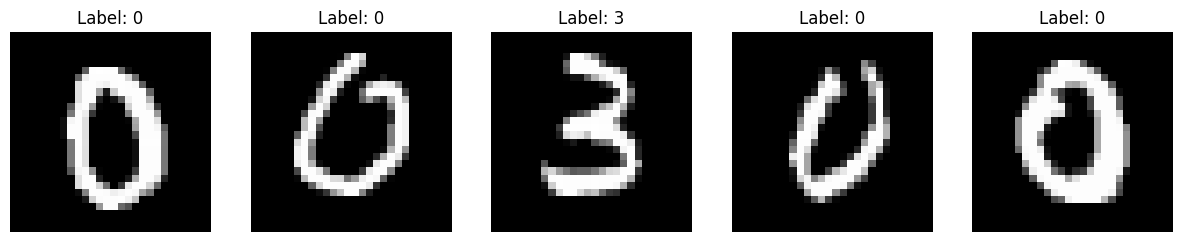

In [22]:
#| hide
import matplotlib.pyplot as plt
def plot_client_samples(partition, num_samples=5):
    fig, axes = plt.subplots(1, num_samples, figsize=(15, 3))
    for i in range(num_samples):
        img = np.array(partition[i]['image']).squeeze()  # Remove channel dimension if present
        label = partition[i]['label']
        axes[i].imshow(img, cmap='gray')
        axes[i].set_title(f"Label: {label}")
        axes[i].axis('off')
    plt.show()

idx = np.random.randint(0, fds.partitioners["train"].num_partitions)
print(idx)
client_data = fds.load_partition(idx, "train")
plot_client_samples(client_data, num_samples=5)

In [23]:
#| hide
for client_idx in range(20):
    client_data = fds.load_partition(client_idx, "train")
    print(f"Client {client_idx}: {np.unique(client_data['label'])}")

Client 0: [0]
Client 1: [6 9]
Client 2: [0 3 7]
Client 3: [0 4 7 8]
Client 4: [0 3 4 5 6]
Client 5: [4 5]
Client 6: [4 9]
Client 7: [0 2]
Client 8: [0 7]
Client 9: [2 7]
Client 10: [1 7]
Client 11: [0 3]
Client 12: [4 8]
Client 13: [7 9]
Client 14: [3 4]
Client 15: [0 5]
Client 16: [6 9]
Client 17: [3 6]
Client 18: [3 9]
Client 19: [0 3]


In [ ]:
#| hide
import nbdev
nbdev.nbdev_export()